In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv('/content/diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.shape

(768, 9)

In [8]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [9]:
df.duplicated().sum()

np.int64(0)

<Axes: >

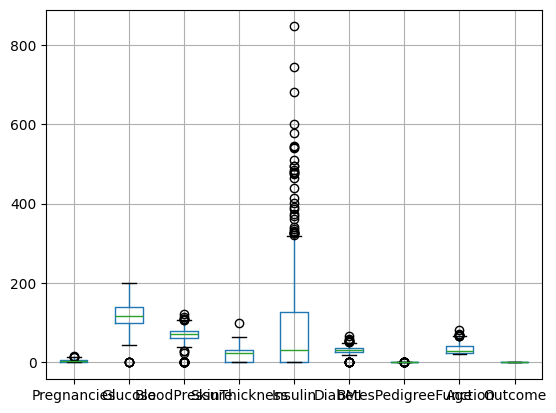

In [10]:
df.boxplot()

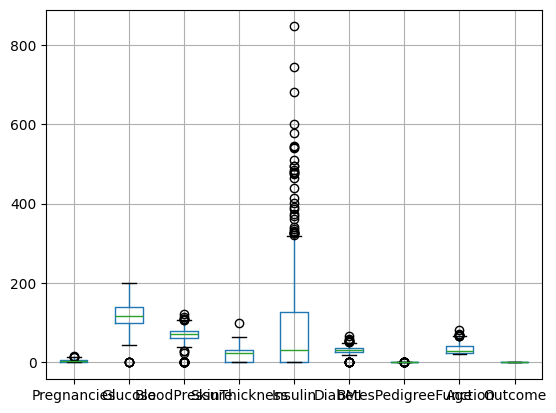

In [11]:
#Checking outliers
df.boxplot()
plt.show()

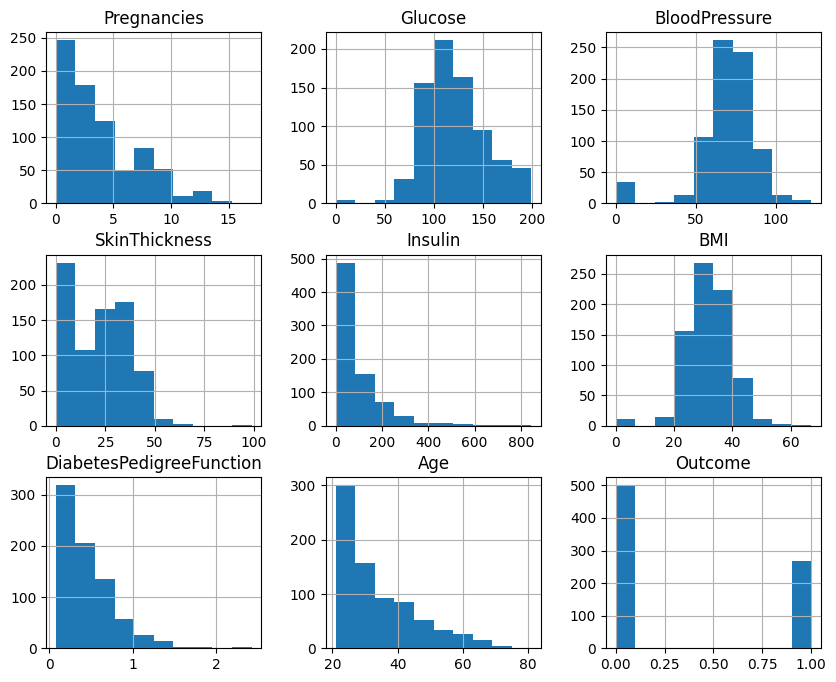

In [15]:
#Histogram
df.hist(figsize=(10,8))
plt.show()

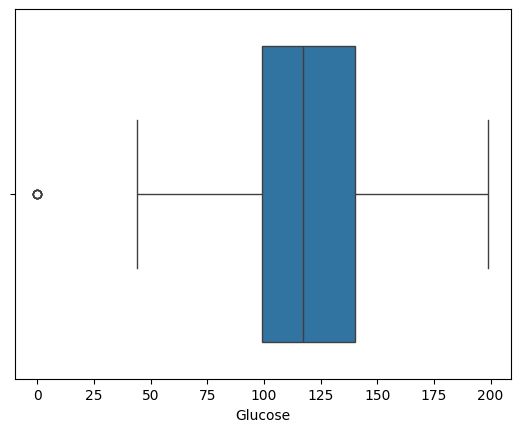

In [16]:
sns.boxplot(x=df['Glucose'])
plt.show()

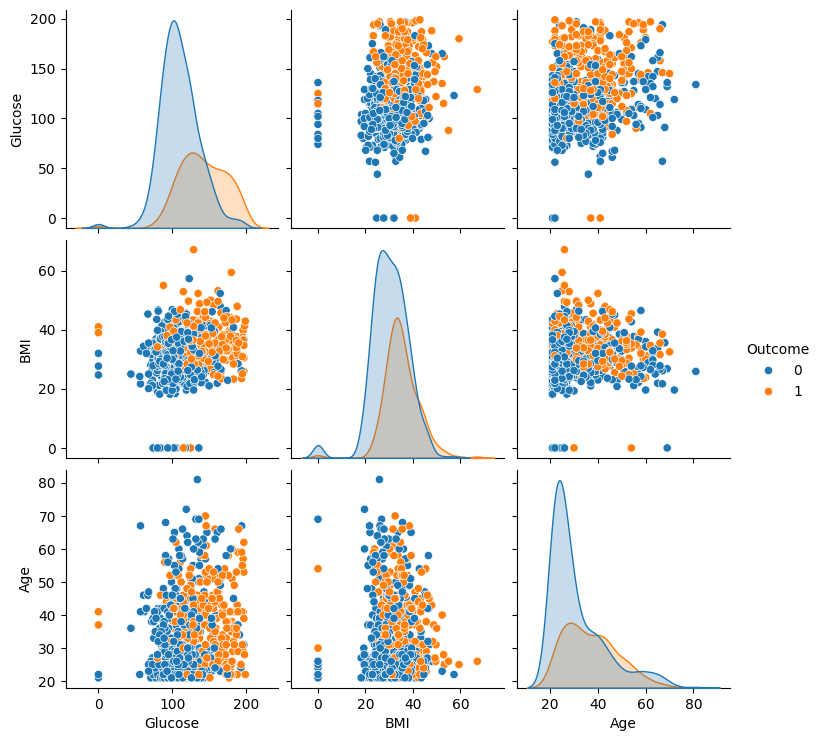

In [17]:
sns.pairplot(df[['Glucose','BMI','Age','Outcome']],
hue='Outcome')

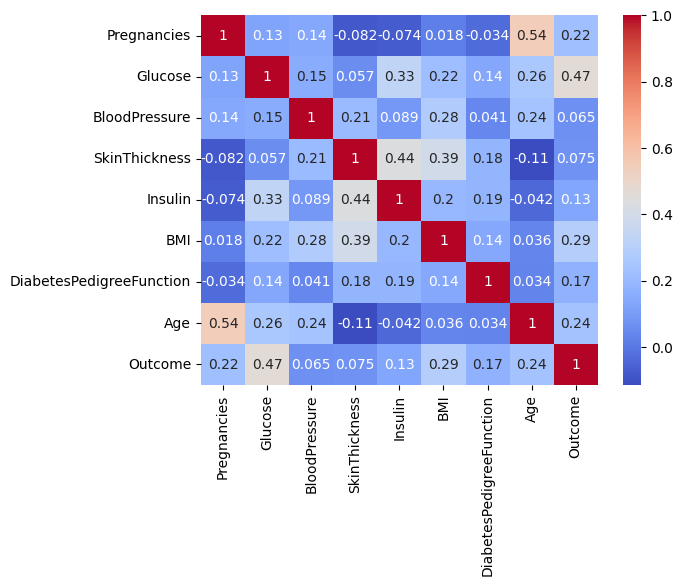

In [18]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [22]:
#zeros in some columns represent missing values.
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in cols:
    df[col] = df[col].replace(0, df[col].median())

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [26]:
from sklearn.metrics import (
     accuracy_score, precision_score, recall_score,
     f1_score, roc_auc_score, roc_curve )

In [28]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]
print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall :', recall_score(y_test, y_pred))
print('F1 Score :', f1_score(y_test, y_pred))
print('ROC-AUC :', roc_auc_score(y_test, y_prob))

Accuracy : 0.7597402597402597
Precision: 0.6730769230769231
Recall : 0.6363636363636364
F1 Score : 0.6542056074766355
ROC-AUC : 0.8179981634527089


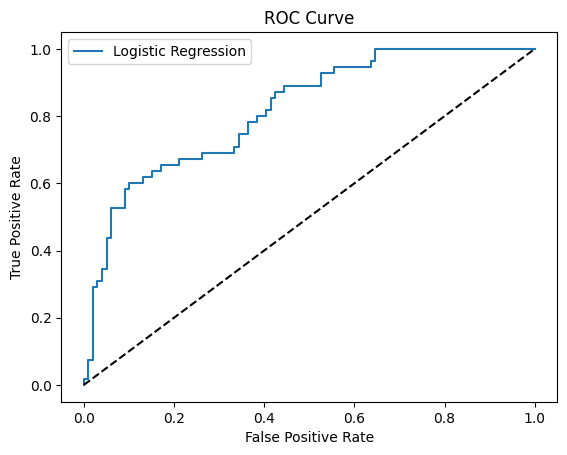

In [29]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


In [30]:
#Coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})
print(coef_df)

                    Feature  Coefficient
0               Pregnancies     0.066199
1                   Glucose     0.038540
2             BloodPressure    -0.014477
3             SkinThickness     0.005408
4                   Insulin    -0.002191
5                       BMI     0.106051
6  DiabetesPedigreeFunction     0.590131
7                       Age     0.033342


Feature significance
Glucose: Strongest positive coefficient → higher glucose increases diabetes probability.
BMI: Positive coefficient → obesity is associated with diabetes.
Age: Positive coefficient → risk increases with age.
DiabetesPedigreeFunction: Positive coefficient → family history contributes to diabetes risk.

Conclusion: Glucose is the most influential predictor in this dataset.

In [34]:
#Streamlit Deployment
import pickle

pickle.dump(model, open('diabetes_model.pkl', 'wb'))

In [50]:
#Streamlit app (app.py)
import streamlit as st
import pickle
import pandas as pd

model = pickle.load(open('diabetes_model.pkl', 'rb'))

st.title('Diabetes Prediction App')

preg = st.number_input('Pregnancies', 0, 20, 1)
glucose = st.number_input('Glucose', 0, 300, 120)
bp = st.number_input('Blood Pressure', 0, 200, 70)
skin = st.number_input('Skin Thickness', 0, 100, 20)
insulin = st.number_input('Insulin', 0, 900, 80)
bmi = st.number_input('BMI', 0.0, 70.0, 25.0)
dpf = st.number_input('Diabetes Pedigree Function', 0.0, 3.0, 0.5)
age = st.number_input('Age', 1, 100, 30)
input_data = pd.DataFrame([[preg, glucose, bp, skin,
                             insulin, bmi, dpf, age]]
                           , columns=['Pregnancies','Glucose',
                                      'BloodPressure','SkinThickness',
                                      'Insulin','BMI',
                                      'DiabetesPedigreeFunction','Age'])
prediction = model.predict(input_data)[0]

if st.button('Predict'):
    if prediction == 1:
        st.error('Diabetes Detected')
    else:
        st.success('No Diabetes Detected')

2026-08-06 08:01:22.033 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-06 08:01:22.039 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-06 08:01:22.044 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-06 08:01:22.046 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-06 08:01:22.051 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-06 08:01:22.055 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-06 08:01:22.057 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-06 08:01:22.062 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [51]:
%%writefile app.py
import streamlit as st
import pickle
import pandas as pd

model = pickle.load(open('diabetes_model.pkl', 'rb'))

st.title('Diabetes Prediction App')

preg = st.number_input('Pregnancies', 0, 20, 1)
glucose = st.number_input('Glucose', 0, 300, 120)
bp = st.number_input('Blood Pressure', 0, 200, 70)
skin = st.number_input('Skin Thickness', 0, 100, 20)
insulin = st.number_input('Insulin', 0, 900, 80)
bmi = st.number_input('BMI', 0.0, 70.0, 25.0)
dpf = st.number_input('Diabetes Pedigree Function', 0.0, 3.0, 0.5)
age = st.number_input('Age', 1, 100, 30)
input_data = pd.DataFrame([[preg, glucose, bp, skin,
                             insulin, bmi, dpf, age]]
                           , columns=['Pregnancies','Glucose',
                                      'BloodPressure','SkinThickness',
                                      'Insulin','BMI',
                                      'DiabetesPedigreeFunction','Age'])
prediction = model.predict(input_data)[0]

if st.button('Predict'):
    if prediction == 1:
        st.error('Diabetes Detected')
    else:
        st.success('No Diabetes Detected')

Writing app.py


In [ ]:
!npm install localtunnel
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
added 22 packages in 5s
⠸
⠸3 packages are looking for funding
⠸  run `npm fund` for details
⠸npm notice
npm notice New major version of npm available! 10.8.2 -> 12.0.2
npm notice Changelog: https://github.com/npm/cli/releases/tag/v12.0.2
npm notice To update run: npm install -g npm@12.0.2
npm notice
⠸⠙

your url is: https://heavy-pianos-win.loca.lt
2026-08-06 08:01:45.431 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.24.7.69:8501

